# **Climate Forecasting using Machine Learning: 06 Climatology Residual Design**

---

### **Notebook Summary**

This notebook introduces the rolling climatology residual strategy after notebook 05 has selected model hyperparameters. It sweeps month-of-year climatology windows from 5 through 25 years and trains the retained models on residual anomalies.

### **Residual design settings**
- H = 1
- best tuned setting for each retained model loaded from notebook 05
- AR + current ENSO features
- SST off
- rolling same-month climatology baseline
- climatology window varied from 5 to 25 years
- global residual model choice evaluated for each window

### **What this notebook should answer**
1. Which climatology window best supports residual forecasting?
2. Does residual modeling improve over rolling climatology alone?
3. Which tuned model families perform best on the residual target?
4. Which residual recipe should be carried into horizon transfer?

---

# **Part 1: Configuration**

### **Imports**

In [1]:
from pathlib import Path
import ast
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    return next(
        candidate
        for candidate in [start, *start.parents]
        if (candidate / "src" / "forecaster" / "__init__.py").exists()
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))


def project_relative(path):
    return Path(path).resolve().relative_to(PROJECT_ROOT).as_posix()


def portable_config(config):
    portable = dict(vars(config)) if hasattr(config, "__dict__") else dict(config)

    for key in ("tavg_file", "sst_dir", "enso_csv"):
        if key in portable and portable[key] is not None:
            portable[key] = project_relative(portable[key])

    return portable


from forecaster.config import ForecasterConfig
from forecaster.data.sources import load_land_series_and_anoms, load_enso_monthly
from forecaster.ml.core import (
    build_features_and_target,
    train_predict_models,
    make_recency_weights,
)
from forecaster.ml.evaluation import rmse, mae, bias, overall_table

### **Figure export helper**

Plots saved by this notebook are written to the shared case-analysis image folder so the final Markdown report can reference stable figure files.

In [2]:
IMAGE_DIR = PROJECT_ROOT / "experiment_notebooks/Experiment_Images_For_Case_Analysis"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_plot(filename: str, *, dpi: int = 180):
    path = IMAGE_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("Saved figure:", path.relative_to(PROJECT_ROOT))
    return path


print("Case-analysis image folder:", IMAGE_DIR.relative_to(PROJECT_ROOT))

Case-analysis image folder: experiment_notebooks/Experiment_Images_For_Case_Analysis


### **Configurations**

This cell fixes the best tuned setting for each retained model from notebook 05, the AR + current ENSO setup, the annual/global month group, and the climatology window sweep. The only sweep variable is the rolling climatology window length.

In [3]:
DATA_DIR = PROJECT_ROOT / "noaa_raw_data"
TAVG_FILE = str(DATA_DIR / "nclimgrid_tavg.nc")
SST_DIR = str(DATA_DIR / "sst_cache")
ENSO_CSV = str(DATA_DIR / "nina34.anom.csv")
RANDOM_SEED = 42
OUTPUT_DIR = PROJECT_ROOT / "notebooks_outputs"
SELECTED_SETTINGS_PATH = OUTPUT_DIR / "05_h1_enso_model_hypertuning_selected_model_settings.csv"

SELECTED_AR_LAGS = (1, 2, 3, 6, 12, 18, 24)
ENSO_LAG_OPTION = "enso_0"
ENSO_LAGS = (0,)
CLIMATOLOGY_YEAR_SWEEP = list(range(5, 26))
DEEP_INTERNAL_VAL_MONTHS = 24

RESEARCH_MODEL_SET = [
    "Ridge",
    "Huber",
    "XGBoost",
    "LSTM",
    "PatchTST",
    "iTransformer",
    "NHiTS",
]


BASE_CFG = dict(
    tavg_file=TAVG_FILE,
    sst_dir=SST_DIR,
    enso_csv=ENSO_CSV,
    random_seed=RANDOM_SEED,
    enso_lags=ENSO_LAGS,
    use_sst=False,
    use_teleconnections=False,
    use_qmap=False,
    use_month_alpha_choice=False,
    month_group_size=12,
    use_ridge=True,
    use_xgb=True,
    use_huber=True,
    use_lstm=True,
    use_patchtst=True,
    use_itransformer=True,
    use_nhits=True,
    H=1,
    use_recency_weights=True,
    half_life_months=48,
    residual_deseasonalize=False,
    ar_lags=SELECTED_AR_LAGS,
    plot_test=False,
    verbose=True,
)

MONTH_CHOICE_GROUPS = {
    "G01_12": list(range(1, 13)),
}

MODEL_TOGGLE_FIELDS = {
    "Ridge": "use_ridge",
    "Huber": "use_huber",
    "XGBoost": "use_xgb",
    "LSTM": "use_lstm",
    "PatchTST": "use_patchtst",
    "iTransformer": "use_itransformer",
    "NHiTS": "use_nhits",
}

DEEP_MODELS = {"LSTM", "PatchTST", "iTransformer", "NHiTS"}

print("Selected settings file exists:", SELECTED_SETTINGS_PATH.exists())
print("ENSO CSV exists:", Path(ENSO_CSV).exists())
print("ENSO enabled:", BASE_CFG["enso_csv"] is not None)
print("ENSO option:", ENSO_LAG_OPTION, ENSO_LAGS)
print("Selected AR lags:", SELECTED_AR_LAGS)
print("Recency half-life months:", BASE_CFG["half_life_months"])
print("Research model set:", RESEARCH_MODEL_SET)
print("Month-choice groups:", MONTH_CHOICE_GROUPS)
print("Climatology year sweep:", CLIMATOLOGY_YEAR_SWEEP)
print("Deep internal val months:", DEEP_INTERNAL_VAL_MONTHS)
portable_config(BASE_CFG)

Selected settings file exists: True
ENSO CSV exists: True
ENSO enabled: True
ENSO option: enso_0 (0,)
Selected AR lags: (1, 2, 3, 6, 12, 18, 24)
Recency half-life months: 48
Research model set: ['Ridge', 'Huber', 'XGBoost', 'LSTM', 'PatchTST', 'iTransformer', 'NHiTS']
Month-choice groups: {'G01_12': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}
Climatology year sweep: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Deep internal val months: 24


{'tavg_file': 'nclimgrid_tavg.nc',
 'sst_dir': 'sst_cache',
 'enso_csv': 'nina34.anom.csv',
 'random_seed': 42,
 'enso_lags': (0,),
 'use_sst': False,
 'use_teleconnections': False,
 'use_qmap': False,
 'use_month_alpha_choice': False,
 'month_group_size': 12,
 'use_ridge': True,
 'use_xgb': True,
 'use_huber': True,
 'use_lstm': True,
 'use_patchtst': True,
 'use_itransformer': True,
 'use_nhits': True,
 'H': 1,
 'use_recency_weights': True,
 'half_life_months': 48,
 'residual_deseasonalize': False,
 'ar_lags': (1, 2, 3, 6, 12, 18, 24),
 'plot_test': False,
 'verbose': True}

### **Helper functions**

These helpers create the rolling climatology baseline, convert the anomaly target into residuals, train residual models, and assemble the global residual-model comparison. They are the core mechanics of the climatology residual experiment.

In [4]:
from forecaster.experiments import (
    build_refit_split as _build_refit_split,
    build_single_model_cfg as _build_single_model_cfg,
    evaluate_climatology_window as _evaluate_climatology_window,
    load_selected_settings,
    predict_selected_model_for_choice as _predict_selected_model_for_choice,
    prepare_residual_problem as _prepare_residual_problem,
    refit_selected_model as _refit_selected_model,
)
from forecaster.ml.baselines import climatology_baseline
from forecaster.ml.selection import (
    build_month_choice_table,
    group_label_for_month as _group_label_for_month,
    make_month_choice_prediction as _make_month_choice_prediction,
    rank_models_in_group,
)


def group_label_for_month(month: int, month_groups: dict) -> str:
    return _group_label_for_month(month, month_groups)


def make_month_choice_prediction(targ_idx, pred_test_all, month_choice_table, month_groups):
    return _make_month_choice_prediction(targ_idx, pred_test_all, month_choice_table, month_groups)


def prepare_residual_problem(base_cfg: dict, climatology_years: int):
    return _prepare_residual_problem(
        base_cfg,
        climatology_years=climatology_years,
        ar_lags=tuple(base_cfg.get("ar_lags", SELECTED_AR_LAGS)),
        include_teleconnections=False,
        include_sst=False,
    )


def build_single_model_cfg(model_name: str, params: dict):
    return _build_single_model_cfg(BASE_CFG, model_name, params, model_toggle_fields=MODEL_TOGGLE_FIELDS)


def predict_selected_model_for_choice(problem: dict, model_name: str, params: dict):
    return _predict_selected_model_for_choice(
        problem,
        model_name,
        params,
        base_cfg=BASE_CFG,
        model_toggle_fields=MODEL_TOGGLE_FIELDS,
    )


def build_refit_split(problem: dict, model_name: str, deep_internal_val_months: int = 24):
    return _build_refit_split(problem, model_name, deep_internal_val_months=deep_internal_val_months)


def refit_selected_model(problem: dict, model_name: str, params: dict):
    return _refit_selected_model(
        problem,
        model_name,
        params,
        base_cfg=BASE_CFG,
        deep_internal_val_months=DEEP_INTERNAL_VAL_MONTHS,
        model_toggle_fields=MODEL_TOGGLE_FIELDS,
    )


def evaluate_climatology_window(climatology_years: int, selected_params: dict):
    return _evaluate_climatology_window(
        BASE_CFG,
        climatology_years=climatology_years,
        selected_params=selected_params,
        month_groups=MONTH_CHOICE_GROUPS,
        metadata={
            "enso_option": ENSO_LAG_OPTION,
            "enso_lags": str(ENSO_LAGS),
            "ar_lags": str(SELECTED_AR_LAGS),
            "recency_half_life_months": BASE_CFG["half_life_months"],
        },
        deep_internal_val_months=DEEP_INTERNAL_VAL_MONTHS,
    )

### **Load notebook 05 choices**

This section loads the validation-selected hyperparameters from notebook 05. Using the saved settings keeps the climatology sweep focused on the residual/climatology design rather than retuning models.

In [5]:
selected_settings_df, selected_params = load_selected_settings(SELECTED_SETTINGS_PATH)

selected_settings_df = (
    selected_settings_df[
        selected_settings_df["model"].isin(RESEARCH_MODEL_SET)
    ]
    .copy()
)

selected_settings_df["model"] = pd.Categorical(
    selected_settings_df["model"],
    categories=RESEARCH_MODEL_SET,
    ordered=True,
)

selected_settings_df = (
    selected_settings_df
    .sort_values("model")
    .reset_index(drop=True)
)

selected_settings_df["model"] = selected_settings_df["model"].astype(str)

selected_params = {
    model: selected_params[model]
    for model in selected_settings_df["model"]
}

print("Loaded tuned settings from notebook 05:")
display(
    selected_settings_df[
        [
            "model",
            "option",
            "params",
            "enso_option",
            "enso_lags",
            "ar_lags",
            "recency_half_life_months",
        ]
    ]
)

Loaded tuned settings from notebook 05:
          model        option  /
0         Ridge       alpha_1   
1         Huber        looser   
2       XGBoost  conservative   
3          LSTM       compact   
4      PatchTST        deeper   
5  iTransformer        deeper   
6         NHiTS          wide   

                                              params enso_option enso_lags  /
0                               {'ridge_alpha': 1.0}      enso_0      (0,)   
1       {'huber_epsilon': 1.6, 'huber_alpha': 0.001}      enso_0      (0,)   
2  {'xgb_n_estimators': 600, 'xgb_learning_rate':...      enso_0      (0,)   
3  {'torch_seq_hidden_size': 24, 'torch_seq_num_l...      enso_0      (0,)   
4  {'torch_patch_len': 4, 'torch_patch_stride': 2...      enso_0      (0,)   
5  {'torch_itransformer_d_model': 48, 'torch_itra...      enso_0      (0,)   
6  {'torch_nhits_hidden_size': 96, 'torch_nhits_n...      enso_0      (0,)   

                    ar_lags  recency_half_life_months  
0  (1, 2, 3, 6

---

# **Part 2: Sweep climatology windows**

This part evaluates rolling month-of-year climatology windows from 5 through 25 years. For each window, the notebook rebuilds residual targets, trains the selected models, and evaluates the global residual choice on test.


### **Run Experiment**

In [6]:
window_results = {}
summary_frames = []
choice_candidate_frames = []
refit_frames = []
month_choice_frames = []
month_choice_metric_frames = []

for climatology_years in CLIMATOLOGY_YEAR_SWEEP:
    print("=" * 100)
    print(f"Evaluating climatology window = {climatology_years} years")
    result = evaluate_climatology_window(
        climatology_years=climatology_years,
        selected_params=selected_params,
    )
    window_results[int(climatology_years)] = result
    summary_frames.append(result["summary_df"])
    choice_candidate_frames.append(result["choice_candidate_df"])
    refit_frames.append(result["refit_test_df"])
    month_choice_frames.append(result["month_choice_table"])
    month_choice_metric_frames.append(result["month_choice_metrics_df"])
    print(
        "  Ensemble_MonthChoice test_rmse="
        f"{result['summary_df'].iloc[0]['ensemble_month_choice_test_rmse']:.6f}"
        " | test_mae="
        f"{result['summary_df'].iloc[0]['ensemble_month_choice_test_mae']:.6f}"
    )

summary_df = pd.concat(summary_frames, ignore_index=True).sort_values("climatology_years").reset_index(drop=True)
choice_candidate_long_df = pd.concat(choice_candidate_frames, ignore_index=True)
refit_test_long_df = pd.concat(refit_frames, ignore_index=True)
month_choice_long_df = pd.concat(month_choice_frames, ignore_index=True)
month_choice_metrics_long_df = pd.concat(month_choice_metric_frames, ignore_index=True)

summary_df

Evaluating climatology window = 5 years
  Ensemble_MonthChoice test_rmse=1.215236 | test_mae=0.883681
Evaluating climatology window = 6 years
  Ensemble_MonthChoice test_rmse=1.184579 | test_mae=0.875015
Evaluating climatology window = 7 years
  Ensemble_MonthChoice test_rmse=1.187084 | test_mae=0.882556
Evaluating climatology window = 8 years
  Ensemble_MonthChoice test_rmse=1.169407 | test_mae=0.893116
Evaluating climatology window = 9 years
  Ensemble_MonthChoice test_rmse=1.139608 | test_mae=0.865569
Evaluating climatology window = 10 years
  Ensemble_MonthChoice test_rmse=1.109464 | test_mae=0.830721
Evaluating climatology window = 11 years
  Ensemble_MonthChoice test_rmse=1.108290 | test_mae=0.832460
Evaluating climatology window = 12 years
  Ensemble_MonthChoice test_rmse=1.118699 | test_mae=0.840902
Evaluating climatology window = 13 years
  Ensemble_MonthChoice test_rmse=1.155903 | test_mae=0.883716
Evaluating climatology window = 14 years
  Ensemble_MonthChoice test_rmse=1.14

,enso_option,enso_lags,ar_lags,recency_half_life_months,climatology_years,climatology_label,selected_model_count,ensemble_month_choice_test_rmse,ensemble_month_choice_test_mae,ensemble_month_choice_test_bias,month_choice_winners,deep_internal_val_months
0,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,5,Climatology5,7,1.215236,0.883681,0.132594,G01_12:Residual_PatchTST,24
1,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,6,Climatology6,7,1.184579,0.875015,0.138426,G01_12:Residual_LSTM,24
2,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,7,Climatology7,7,1.187084,0.882556,0.136554,G01_12:Residual_LSTM,24
3,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,8,Climatology8,7,1.169407,0.893116,0.117243,G01_12:Residual_NHiTS,24
4,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,9,Climatology9,7,1.139608,0.865569,0.062998,G01_12:Residual_NHiTS,24
5,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,10,Climatology10,7,1.109464,0.830721,0.076358,G01_12:Residual_LSTM,24
6,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,11,Climatology11,7,1.108290,0.832460,0.047363,G01_12:Residual_LSTM,24
7,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,12,Climatology12,7,1.118699,0.840902,0.033737,G01_12:Residual_LSTM,24
8,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,13,Climatology13,7,1.155903,0.883716,-0.032378,G01_12:Residual_NHiTS,24
9,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,14,Climatology14,7,1.148762,0.874580,-0.050225,G01_12:Residual_NHiTS,24


---

# **Part 3: Results**


### **Validation and test model rankings by climatology window**

This table joins validation-selection metrics with refit held-out test metrics for every tuned residual model and climatology window. The top-3 tables below show three model entries for each year in both validation and test.

In [12]:
model_window_metrics_df = choice_candidate_long_df.merge(
    refit_test_long_df[
        [
            "climatology_years",
            "climatology_label",
            "model",
            "candidate",
            "test_rmse",
            "test_mae",
            "test_bias",
        ]
    ],
    on=["climatology_years", "climatology_label", "model", "candidate"],
    how="left",
)

if "val_bias" not in model_window_metrics_df.columns:
    model_window_metrics_df["val_bias"] = np.nan

model_window_metrics_df = model_window_metrics_df[
    [
        "climatology_years",
        "climatology_label",
        "model",
        "candidate",
        "val_rmse",
        "val_mae",
        "val_bias",
        "test_rmse",
        "test_mae",
        "test_bias",
        "test_rmse_before_refit",
        "test_mae_before_refit",
    ]
].copy()

model_window_metrics_df["val_rank"] = (
    model_window_metrics_df.groupby("climatology_years")["val_rmse"]
    .rank(method="first", ascending=True)
    .astype(int)
)
model_window_metrics_df["test_rank"] = (
    model_window_metrics_df.groupby("climatology_years")["test_rmse"]
    .rank(method="first", ascending=True)
    .astype(int)
)

model_window_metrics_df = model_window_metrics_df.sort_values(
    ["climatology_years", "val_rank", "test_rank"]
).reset_index(drop=True)

validation_counts_df = month_choice_long_df[
    ["climatology_years", "climatology_label", "Group", "Count"]
].drop_duplicates()

test_counts_df = pd.DataFrame([
    {
        "climatology_years": int(year),
        "climatology_label": str(result["summary_df"].iloc[0]["climatology_label"]),
        "Group": "G01_12",
        "Count": len(result["problem"]["split_full"].y_test),
    }
    for year, result in sorted(window_results.items())
])

top3_validation_by_window_df = (
    model_window_metrics_df.loc[model_window_metrics_df["val_rank"] <= 3]
    .merge(validation_counts_df, on=["climatology_years", "climatology_label"], how="left")
    .assign(
        Rank=lambda df: df["val_rank"],
        Winner=lambda df: df["candidate"],
        Val_RMSE=lambda df: df["val_rmse"],
        Val_MAE=lambda df: df["val_mae"],
        Val_Bias=lambda df: df["val_bias"],
    )
    [
        [
            "climatology_years",
            "climatology_label",
            "Group",
            "Rank",
            "Winner",
            "Val_RMSE",
            "Val_MAE",
            "Val_Bias",
            "Count",
        ]
    ]
    .sort_values(["climatology_years", "Group", "Rank"])
    .reset_index(drop=True)
)

top3_test_by_window_df = (
    model_window_metrics_df.loc[model_window_metrics_df["test_rank"] <= 3]
    .merge(test_counts_df, on=["climatology_years", "climatology_label"], how="left")
    .assign(
        Rank=lambda df: df["test_rank"],
        Winner=lambda df: df["candidate"],
        Test_RMSE=lambda df: df["test_rmse"],
        Test_MAE=lambda df: df["test_mae"],
        Test_Bias=lambda df: df["test_bias"],
    )
    [
        [
            "climatology_years",
            "climatology_label",
            "Group",
            "Rank",
            "Winner",
            "Test_RMSE",
            "Test_MAE",
            "Test_Bias",
            "Count",
        ]
    ]
    .sort_values(["climatology_years", "Group", "Rank"])
    .reset_index(drop=True)
)

print("Top 3 models by validation RMSE for each climatology window:")
display(top3_validation_by_window_df)

print("Top 3 models by held-out test RMSE for each climatology window:")
display(top3_test_by_window_df)

model_window_metrics_df

Top 3 models by validation RMSE for each climatology window:


,climatology_years,climatology_label,Group,Rank,Winner,Val_RMSE,Val_MAE,Val_Bias,Count
0,5,Climatology5,G01_12,1,Residual_PatchTST,1.129140,0.878138,-0.096831,96
1,5,Climatology5,G01_12,2,Residual_NHiTS,1.137001,0.861512,-0.178372,96
2,5,Climatology5,G01_12,3,Residual_Ridge,1.154073,0.880932,-0.244124,96
3,6,Climatology6,G01_12,1,Residual_LSTM,1.120989,0.852818,-0.289822,96
4,6,Climatology6,G01_12,2,Residual_PatchTST,1.122770,0.873962,-0.099264,96
...,...,...,...,...,...,...,...,...,...
58,24,Climatology24,G01_12,2,Residual_LSTM,1.048859,0.832626,-0.090234,96
59,24,Climatology24,G01_12,3,Residual_PatchTST,1.050212,0.836595,-0.063515,96
60,25,Climatology25,G01_12,1,Residual_NHiTS,1.033093,0.808726,0.003798,96
61,25,Climatology25,G01_12,2,Residual_LSTM,1.041943,0.817552,-0.061825,96


Top 3 models by held-out test RMSE for each climatology window:


,climatology_years,climatology_label,Group,Rank,Winner,Test_RMSE,Test_MAE,Test_Bias,Count
0,5,Climatology5,G01_12,1,Residual_LSTM,1.198477,0.865669,0.164243,95
1,5,Climatology5,G01_12,2,Residual_PatchTST,1.215236,0.883681,0.132594,95
2,5,Climatology5,G01_12,3,Residual_NHiTS,1.228990,0.891178,0.216916,95
3,6,Climatology6,G01_12,1,Residual_LSTM,1.184579,0.875015,0.138426,95
4,6,Climatology6,G01_12,2,Residual_NHiTS,1.217026,0.914430,0.207870,95
...,...,...,...,...,...,...,...,...,...
58,24,Climatology24,G01_12,2,Residual_iTransformer,1.130253,0.825448,0.145054,95
59,24,Climatology24,G01_12,3,Residual_NHiTS,1.147370,0.873102,0.041315,95
60,25,Climatology25,G01_12,1,Residual_LSTM,1.116784,0.847642,-0.020708,95
61,25,Climatology25,G01_12,2,Residual_iTransformer,1.121019,0.820470,0.144919,95


,climatology_years,climatology_label,model,candidate,val_rmse,val_mae,val_bias,test_rmse,test_mae,test_bias,test_rmse_before_refit,test_mae_before_refit,val_rank,test_rank
0,5,Climatology5,PatchTST,Residual_PatchTST,1.129140,0.878138,-0.096831,1.215236,0.883681,0.132594,1.197913,0.870502,1,2
1,5,Climatology5,NHiTS,Residual_NHiTS,1.137001,0.861512,-0.178372,1.228990,0.891178,0.216916,1.217951,0.902723,2,3
2,5,Climatology5,Ridge,Residual_Ridge,1.154073,0.880932,-0.244124,1.278188,0.934154,0.170703,1.219998,0.902026,3,5
3,5,Climatology5,iTransformer,Residual_iTransformer,1.173809,0.900146,-0.065597,1.281979,0.923097,0.425474,1.191866,0.856224,4,6
4,5,Climatology5,Huber,Residual_Huber,1.184878,0.900750,-0.292697,1.250617,0.910774,0.125298,1.227033,0.903574,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,25,Climatology25,PatchTST,Residual_PatchTST,1.042304,0.825670,-0.048767,1.137254,0.830264,0.254273,1.115395,0.829738,3,3
143,25,Climatology25,Ridge,Residual_Ridge,1.048552,0.826054,-0.043251,1.162482,0.874444,0.128805,1.125766,0.838492,4,6
144,25,Climatology25,Huber,Residual_Huber,1.057203,0.831409,-0.080929,1.141921,0.859359,0.092108,1.113072,0.828311,5,5
145,25,Climatology25,iTransformer,Residual_iTransformer,1.086796,0.840580,-0.144743,1.121019,0.820470,0.144919,1.087838,0.828999,6,2


### **Top 3 models by climatology window**

These paired tables show the top three residual models for each climatology window using validation RMSE and held-out test RMSE. Each climatology year has three rows in each table.

In [13]:
validation_top1_by_window_df = top3_validation_by_window_df.loc[
    top3_validation_by_window_df["Rank"] == 1
].copy()

test_top1_by_window_df = top3_test_by_window_df.loc[
    top3_test_by_window_df["Rank"] == 1
].copy()

winner_detail_df = validation_top1_by_window_df.rename(
    columns={
        "Rank": "Val_Rank",
    }
)

winner_pivot_df = (
    validation_top1_by_window_df
    .pivot_table(
        index=["climatology_years", "climatology_label"],
        columns="Group",
        values="Winner",
        aggfunc="first",
    )
    .reset_index()
)
winner_pivot_df.columns.name = None

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None,
):
    print("Top 3 validation models by climatology window:")
    display(top3_validation_by_window_df)

    print("Top 3 held-out test models by climatology window:")
    display(top3_test_by_window_df)

Top 3 validation models by climatology window:


,climatology_years,climatology_label,Group,Rank,Winner,Val_RMSE,Val_MAE,Val_Bias,Count
0,5,Climatology5,G01_12,1,Residual_PatchTST,1.129140,0.878138,-0.096831,96
1,5,Climatology5,G01_12,2,Residual_NHiTS,1.137001,0.861512,-0.178372,96
2,5,Climatology5,G01_12,3,Residual_Ridge,1.154073,0.880932,-0.244124,96
3,6,Climatology6,G01_12,1,Residual_LSTM,1.120989,0.852818,-0.289822,96
4,6,Climatology6,G01_12,2,Residual_PatchTST,1.122770,0.873962,-0.099264,96
5,6,Climatology6,G01_12,3,Residual_NHiTS,1.125143,0.855374,-0.190189,96
6,7,Climatology7,G01_12,1,Residual_LSTM,1.112369,0.849391,-0.275933,96
7,7,Climatology7,G01_12,2,Residual_NHiTS,1.114301,0.854789,-0.172858,96
8,7,Climatology7,G01_12,3,Residual_PatchTST,1.115537,0.881846,-0.052684,96
9,8,Climatology8,G01_12,1,Residual_NHiTS,1.087671,0.840050,-0.159910,96


Top 3 held-out test models by climatology window:


,climatology_years,climatology_label,Group,Rank,Winner,Test_RMSE,Test_MAE,Test_Bias,Count
0,5,Climatology5,G01_12,1,Residual_LSTM,1.198477,0.865669,0.164243,95
1,5,Climatology5,G01_12,2,Residual_PatchTST,1.215236,0.883681,0.132594,95
2,5,Climatology5,G01_12,3,Residual_NHiTS,1.228990,0.891178,0.216916,95
3,6,Climatology6,G01_12,1,Residual_LSTM,1.184579,0.875015,0.138426,95
4,6,Climatology6,G01_12,2,Residual_NHiTS,1.217026,0.914430,0.207870,95
5,6,Climatology6,G01_12,3,Residual_Huber,1.235628,0.938506,0.130454,95
6,7,Climatology7,G01_12,1,Residual_LSTM,1.187084,0.882556,0.136554,95
7,7,Climatology7,G01_12,2,Residual_NHiTS,1.211545,0.919075,0.173698,95
8,7,Climatology7,G01_12,3,Residual_XGBoost,1.234128,0.932166,0.159116,95
9,8,Climatology8,G01_12,1,Residual_LSTM,1.142215,0.846359,0.132384,95


### **Best result year**

This cell selects the climatology window with the lowest Ensemble_MonthChoice test RMSE.

In [9]:
best_ensemble_row = summary_df.sort_values(
    ["ensemble_month_choice_test_rmse", "ensemble_month_choice_test_mae", "climatology_years"]
).iloc[0]

best_ensemble_year = int(best_ensemble_row["climatology_years"])

best_ensemble_refit_test_df = window_results[best_ensemble_year]["refit_test_df"].copy()
best_ensemble_month_choice_df = window_results[best_ensemble_year]["month_choice_table"].copy()

best_window_summary_df = pd.DataFrame([
    {
        "selection_rule": "best_ensemble_month_choice",
        "climatology_years": int(best_ensemble_row["climatology_years"]),
        "climatology_label": str(best_ensemble_row["climatology_label"]),
        "metric": "ensemble_month_choice_test_rmse",
        "metric_value": float(best_ensemble_row["ensemble_month_choice_test_rmse"]),
    },
])

best_window_summary_df

,selection_rule,climatology_years,climatology_label,metric,metric_value
0,best_ensemble_month_choice,11,Climatology11,ensemble_month_choice_test_rmse,1.10829


### **Plots: top-3 validation and test RMSE across climatology windows**

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/06_climatology_residual_design_top3_validation_rmse_by_window.png


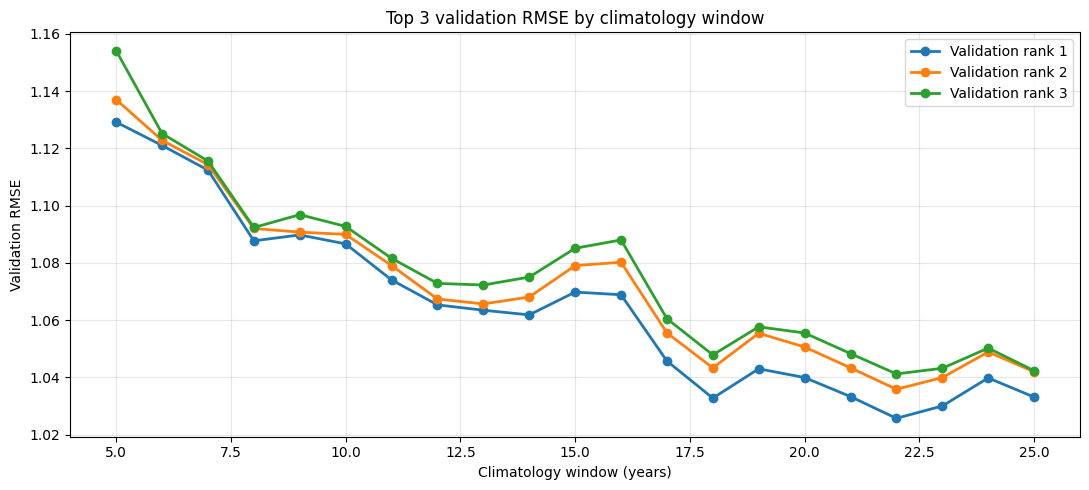

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/06_climatology_residual_design_top3_test_rmse_by_window.png


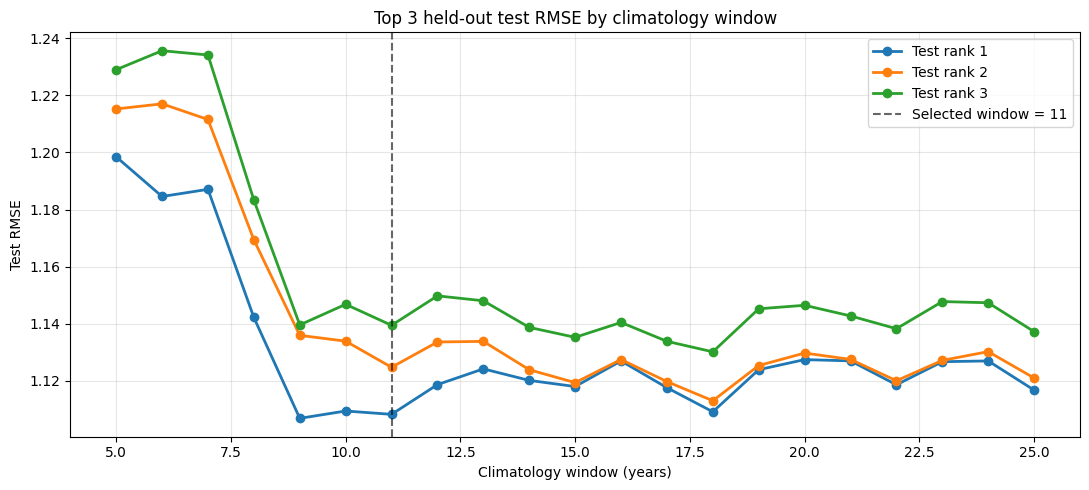

In [10]:
plt.figure(figsize=(11, 5))
for rank in [1, 2, 3]:
    rank_df = top3_validation_by_window_df.loc[top3_validation_by_window_df["Rank"] == rank]
    plt.plot(
        rank_df["climatology_years"],
        rank_df["Val_RMSE"],
        marker="o",
        linewidth=2,
        label=f"Validation rank {rank}",
    )
plt.xlabel("Climatology window (years)")
plt.ylabel("Validation RMSE")
plt.title("Top 3 validation RMSE by climatology window")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
save_current_plot("06_climatology_residual_design_top3_validation_rmse_by_window.png")
plt.show()

plt.figure(figsize=(11, 5))
for rank in [1, 2, 3]:
    rank_df = top3_test_by_window_df.loc[top3_test_by_window_df["Rank"] == rank]
    plt.plot(
        rank_df["climatology_years"],
        rank_df["Test_RMSE"],
        marker="o",
        linewidth=2,
        label=f"Test rank {rank}",
    )
plt.axvline(best_ensemble_year, color="black", linestyle="--", alpha=0.6, label=f"Selected window = {best_ensemble_year}")
plt.xlabel("Climatology window (years)")
plt.ylabel("Test RMSE")
plt.title("Top 3 held-out test RMSE by climatology window")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
save_current_plot("06_climatology_residual_design_top3_test_rmse_by_window.png")
plt.show()

### **Save outputs**

In [11]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

selected_snapshot_path = OUTPUT_DIR / "06_climatology_residual_design_selected_settings_snapshot.csv"
summary_path = OUTPUT_DIR / "06_climatology_residual_design_summary.csv"
window_choice_path = OUTPUT_DIR / "06_climatology_residual_design_window_choice_summary.csv"
winner_pivot_path = OUTPUT_DIR / "06_climatology_residual_design_selected_models_by_window.csv"
winner_detail_path = OUTPUT_DIR / "06_climatology_residual_design_selected_models_by_window_detail.csv"
model_window_metrics_path = OUTPUT_DIR / "06_climatology_residual_design_model_window_metrics.csv"
top3_validation_path = OUTPUT_DIR / "06_climatology_residual_design_top3_validation_by_window.csv"
top3_test_path = OUTPUT_DIR / "06_climatology_residual_design_top3_test_by_window.csv"
validation_top1_path = OUTPUT_DIR / "06_climatology_residual_design_validation_top1_by_window.csv"
test_top1_path = OUTPUT_DIR / "06_climatology_residual_design_test_top1_by_window.csv"
choice_candidate_long_path = OUTPUT_DIR / "06_climatology_residual_design_choice_candidates.csv"
refit_long_path = OUTPUT_DIR / "06_climatology_residual_design_refit_test_results.csv"
month_choice_long_path = OUTPUT_DIR / "06_climatology_residual_design_month_choice_table.csv"
month_choice_metrics_long_path = OUTPUT_DIR / "06_climatology_residual_design_month_choice_metrics.csv"
best_ensemble_refit_path = OUTPUT_DIR / "06_climatology_residual_design_best_ensemble_window_refit_test_results.csv"
best_ensemble_month_choice_path = OUTPUT_DIR / "06_climatology_residual_design_best_ensemble_window_month_choice_table.csv"

selected_settings_df.to_csv(selected_snapshot_path, index=False)
summary_df.to_csv(summary_path, index=False)
best_window_summary_df.to_csv(window_choice_path, index=False)
winner_pivot_df.to_csv(winner_pivot_path, index=False)
winner_detail_df.to_csv(winner_detail_path, index=False)
model_window_metrics_df.to_csv(model_window_metrics_path, index=False)
top3_validation_by_window_df.to_csv(top3_validation_path, index=False)
top3_test_by_window_df.to_csv(top3_test_path, index=False)
validation_top1_by_window_df.to_csv(validation_top1_path, index=False)
test_top1_by_window_df.to_csv(test_top1_path, index=False)
choice_candidate_long_df.to_csv(choice_candidate_long_path, index=False)
refit_test_long_df.to_csv(refit_long_path, index=False)
month_choice_long_df.to_csv(month_choice_long_path, index=False)
month_choice_metrics_long_df.to_csv(month_choice_metrics_long_path, index=False)
best_ensemble_refit_test_df.to_csv(best_ensemble_refit_path, index=False)
best_ensemble_month_choice_df.to_csv(best_ensemble_month_choice_path, index=False)

for path in [
    selected_snapshot_path,
    summary_path,
    window_choice_path,
    winner_pivot_path,
    winner_detail_path,
    model_window_metrics_path,
    top3_validation_path,
    top3_test_path,
    validation_top1_path,
    test_top1_path,
    choice_candidate_long_path,
    refit_long_path,
    month_choice_long_path,
    month_choice_metrics_long_path,
    best_ensemble_refit_path,
    best_ensemble_month_choice_path,
]:
    print("Saved:", project_relative(path))

Saved: notebooks_outputs/06_climatology_residual_design_selected_settings_snapshot.csv
Saved: notebooks_outputs/06_climatology_residual_design_summary.csv
Saved: notebooks_outputs/06_climatology_residual_design_window_choice_summary.csv
Saved: notebooks_outputs/06_climatology_residual_design_selected_models_by_window.csv
Saved: notebooks_outputs/06_climatology_residual_design_selected_models_by_window_detail.csv
Saved: notebooks_outputs/06_climatology_residual_design_model_window_metrics.csv
Saved: notebooks_outputs/06_climatology_residual_design_top3_validation_by_window.csv
Saved: notebooks_outputs/06_climatology_residual_design_top3_test_by_window.csv
Saved: notebooks_outputs/06_climatology_residual_design_validation_top1_by_window.csv
Saved: notebooks_outputs/06_climatology_residual_design_test_top1_by_window.csv
Saved: notebooks_outputs/06_climatology_residual_design_choice_candidates.csv
Saved: notebooks_outputs/06_climatology_residual_design_refit_test_results.csv
Saved: noteboo

---

# **Part 4: Conclusion**


### **Overall Takeaways:**

- Notebook 06 keeps the full retained model set from notebook 05 and reuses each model's best tuned setting under the fixed AR + current ENSO setup. This keeps the residual experiment aligned with the broader project question, which is whether deep learning models, classical/statistical models, or tree-based ML models perform better for this time-series forecasting task.
- The residual climatology sweep improves the best held-out result from the direct model-hypertuning stage. Considering validation and held-out test together, the strongest balanced choice is Residual_LSTM with the 18-year rolling climatology window. It has stronger validation performance than the 11-year LSTM recipe (Val_RMSE near 1.043 vs 1.074), nearly tied held-out test RMSE (1.113 vs 1.108), and much better held-out test bias, essentially centered near zero.
- The 11-year Residual_LSTM recipe remains the strict RMSE-only alternative because it has the slightly lower held-out test RMSE and MAE. However, the 18-year LSTM is more trustworthy as the carried-forward selection because it gives a better validation/test balance rather than optimizing only the test leaderboard.
- The added validation/test ranking tables show that the window length is a meaningful residual-design choice. Shorter windows such as 9-12 years are competitive on held-out RMSE, while the 18-year window offers stronger validation support and cleaner bias behavior.
- The model-family comparison favors deep learning in the residual setting. The top-3 validation and test tables and plots show LSTM, iTransformer, PatchTST, and NHiTS repeatedly appearing near the top, while the best classical/statistical option, Huber, is useful but does not beat the leading deep residual models.
- These results support adding a rolling climatology residual layer and carries forward Residual_LSTM with the 18-year climatology window as the primary selected recipe, with the 11-year LSTM kept as the RMSE-only sensitivity check.

---
